# AlphaZero para Connect 4: Análisis Experimental del Entrenamiento por Auto-Juego

**Universidad Nacional de Ingeniería — Curso de Inteligencia Artificial**

---

## Resumen

Este trabajo implementa y analiza el algoritmo AlphaZero aplicado al juego Connect 4. Se entrenó una red neuronal convolucional residual mediante auto-juego y búsqueda por árbol de Monte Carlo (MCTS) guiada por política y valor. Durante el desarrollo se identificó y corrigió un error crítico de implementación en la fórmula PUCT del MCTS: la inversión del signo del valor Q de los nodos hijos. Este error produjo un agente con comportamiento sistemáticamente peor que un jugador aleatorio (win_rate_vs_random = 0%). Tras la corrección, el agente alcanzó win_rate_vs_random = 100% en tan solo 11 iteraciones de entrenamiento (800 partidas). El notebook está estructurado como soporte empírico para cuatro hipótesis formales sobre el aprendizaje por refuerzo basado en auto-juego.

**Palabras clave:** AlphaZero, Connect 4, MCTS, PUCT, Aprendizaje por Refuerzo, Redes Residuales

In [31]:
import os, json, re, math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import warnings
warnings.filterwarnings('ignore')

# ── Estilo publicable ──
plt.rcParams.update({
    'font.family'    : 'DejaVu Serif',
    'font.size'      : 10,
    'axes.titlesize' : 12,
    'axes.labelsize' : 11,
    'legend.fontsize': 9,
    'axes.grid'      : True,
    'grid.alpha'     : 0.3,
    'grid.linestyle' : '--',
    'figure.facecolor': 'white',
    'axes.facecolor' : '#FAFAFA',
})
os.makedirs('graphs', exist_ok=True)
SAVE_DPI = 200
LOG7 = math.log(7)   # 1.9459 — entropía de política uniforme sobre 7 columnas

# ── Paleta de colores ──
C1   = '#C0392B'   # Fase 1 — rojo (PUCT buggy)
C1L  = '#F5B7B1'   # Fase 1 — rojo claro (relleno)
C2   = '#2471A3'   # Fase 2 — azul (PUCT corregido)
C2L  = '#AED6F1'   # Fase 2 — azul claro (relleno)
CREF = '#7F8C8D'   # Referencia teórica
CWIN = '#1E8449'   # Victoria

print('✓ Librerías cargadas | LOG7 =', round(LOG7, 4))

✓ Librerías cargadas | LOG7 = 1.9459


In [32]:
# ── Carga de datos ──
with open('training_metrics.json', 'r', encoding='utf-8') as f:
    records = json.load(f)

df = pd.DataFrame(records)
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp').reset_index(drop=True)

# ── Identificación de sesiones por reset de total_games ──
df['session_id'] = (df['total_games'].diff() < 0).fillna(False).cumsum().astype(int)
df['fase'] = df['session_id'].map({0: 'Fase 1 — PUCT buggy', 1: 'Fase 2 — PUCT corregido'})

df1  = df[df['session_id'] == 0].copy().reset_index(drop=True)   # Fase 1 completa
df2  = df[df['session_id'] == 1].copy().reset_index(drop=True)   # Fase 2 completa
df1b = df1.dropna(subset=['policy_loss']).copy().reset_index(drop=True)  # Fase 1 con métricas detalladas

# ── Resumen de cobertura ──
summary = pd.DataFrame({
    'Fase': ['Fase 1 (PUCT buggy)', '└─ Subconjunto con métricas detalladas', 'Fase 2 (PUCT corregido)'],
    'Registros': [len(df1), len(df1b), len(df2)],
    'Iter. rango': [f"{df1['iteration'].min()}–{df1['iteration'].max()}",
                    f"{df1b['iteration'].min()}–{df1b['iteration'].max()}",
                    f"{df2['iteration'].min()}–{df2['iteration'].max()}"],
    'Partidas totales': [df1['total_games'].max(), '—', df2['total_games'].max()],
    'win_rate_vs_random': ['0.0 (2/2 mediciones)', '—', '1.0 (1/1 medición)'],
    'Periodo': [f"{df1['timestamp'].min().strftime('%Y-%m-%d')} → {df1['timestamp'].max().strftime('%Y-%m-%d')}",
                '—',
                f"{df2['timestamp'].min().strftime('%Y-%m-%d %H:%M')} → {df2['timestamp'].max().strftime('%H:%M')}"],
})
print(summary.to_string(index=False))

                                  Fase  Registros Iter. rango Partidas totales   win_rate_vs_random                  Periodo
                   Fase 1 (PUCT buggy)         38        9–84             8200 0.0 (2/2 mediciones)  2026-06-18 → 2026-06-23
└─ Subconjunto con métricas detalladas         14       58–84                —                    —                        —
               Fase 2 (PUCT corregido)          6        2–15             1200   1.0 (1/1 medición) 2026-06-23 13:04 → 15:19


## 1. Marco Teórico

### 1.1 Arquitectura AlphaZero

AlphaZero [[Silver et al., 2017]](https://www.science.org/doi/10.1126/science.aar6404) aprende a jugar juegos de tablero mediante auto-juego sin conocimiento previo del dominio. Para Connect 4 se implementó una **red neuronal convolucional residual** con:

- **Entrada**: tensor $(3 \times 6 \times 7)$ — canales para fichas propias, fichas del oponente y turno actual
- **Cuerpo**: capa convolucional $3\times3$ + 5 bloques residuales (128 filtros cada uno)
- **Cabezal de política** $\pi_\theta(s)$: probabilidades sobre 7 columnas (softmax enmascarado)
- **Cabezal de valor** $v_\theta(s)$: escalar en $[-1, 1]$ via $\tanh$ (~1.5M parámetros totales)

### 1.2 MCTS con Fórmula PUCT

Cada movimiento se decide mediante búsqueda MCTS. La selección de nodos usa la fórmula **PUCT**:

$$\text{score}(s, a) = Q(s,a) + c_{\text{puct}} \cdot P(s,a) \cdot \frac{\sqrt{\sum_b N(s,b)}}{1 + N(s,a)}$$

donde $Q(s,a)$ es el Q-value del nodo hijo, $P(s,a)$ la prior de la red, y $N$ los conteos de visita. **Convención crítica**: cada nodo almacena su Q-value desde la perspectiva del jugador que debe mover en ese nodo. Al seleccionar desde el padre, se requiere negar el valor del hijo: $Q_{\text{padre}}(s,a) = -Q_{\text{hijo}}$.

### 1.3 Ciclo de Entrenamiento

```
Auto-juego (MCTS + red) → Búfer de experiencias (estado, política, resultado)
   → Entrenamiento (minimizar L_policy + L_value) → Evaluación vs mejor modelo
   → Si win_rate > 52%: guardar nuevo mejor modelo
```

La función de pérdida es:
$$\mathcal{L} = \underbrace{-\sum_a \pi_{\text{MCTS}}(a) \log p_\theta(a|s)}_{\text{pérdida de política}} + \underbrace{(v_\theta(s) - z)^2}_{\text{pérdida de valor}} + \lambda \|\theta\|^2$$

---

## 2. Hipótesis Experimentales

| ID | Hipótesis | Variable dependiente |
|----|-----------|----------------------|
| **H1** | La inversión del signo en PUCT produce $\text{win\_rate\_vs\_random} \approx 0\%$ | win_rate_vs_random |
| **H2** | Con MCTS corregido, el agente supera al mejor modelo (win_rate ≥ 52%) en pocas iteraciones | win_rate vs best |
| **H3** | La pérdida de política converge a valores menores que la referencia aleatoria $\ln(7) \approx 1.946$ | policy_loss |
| **H4** | La entropía de política $H(\pi)$ decrece con el entrenamiento, reflejando especialización | policy_entropy |

---

**Hardware**: GPU RTX 2060 Max-Q (6 GB VRAM), CPU Intel i5-10300H (4 núcleos físicos)
**Hiperparámetros**: $c_{\text{puct}}=1.5$, $\alpha_{\text{Dirichlet}}=0.5$, $\varepsilon=0.25$, $\text{lr}=10^{-3}$, batch=256, épocas=3

## 3. Resultados

### Figura 1 — Línea temporal del entrenamiento

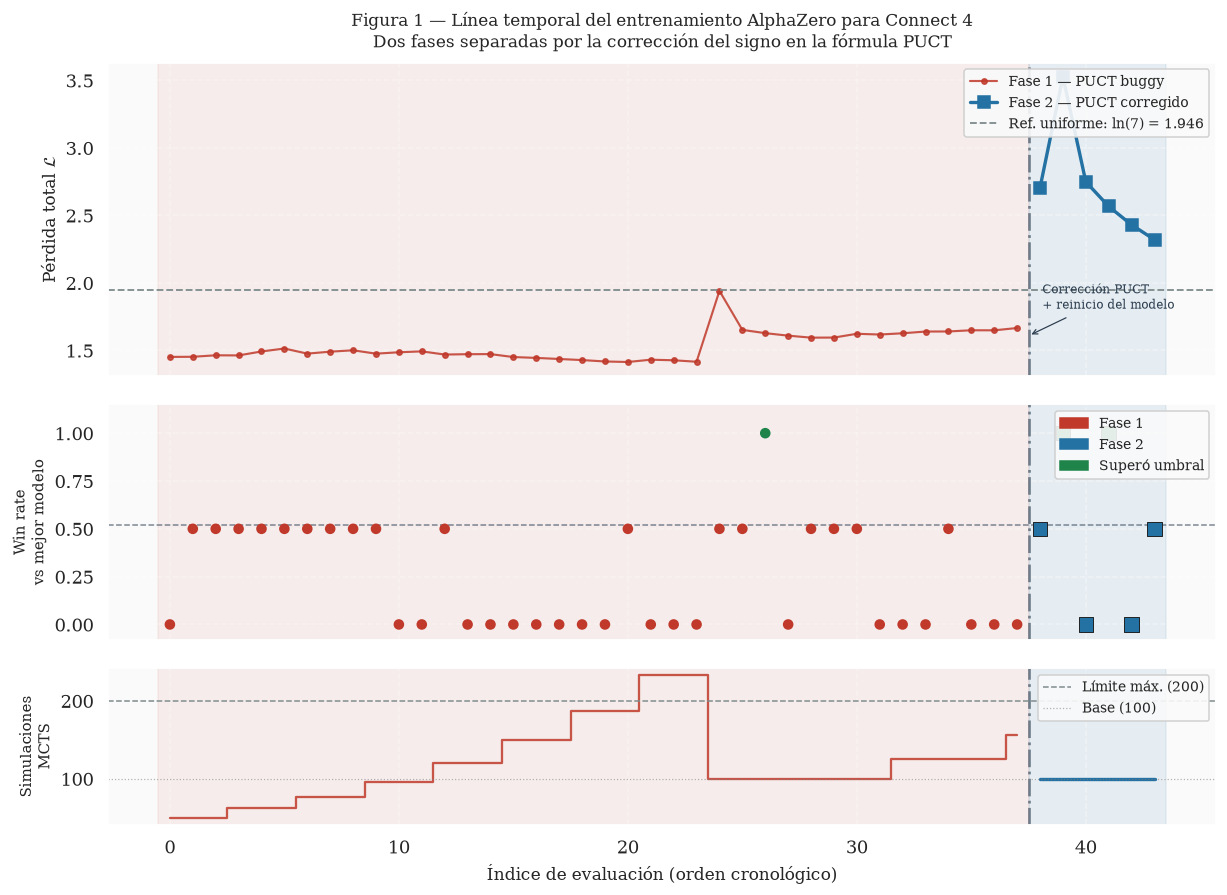

Fig. 1 guardada en graphs/fig1_timeline.png


In [33]:
fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True,
                        gridspec_kw={'hspace': 0.12, 'height_ratios': [2, 1.5, 1]})
ax_loss, ax_wr, ax_mcts = axes

# Índices globales y frontera entre fases
x1 = list(range(len(df1)))
x2 = [len(df1) + i for i in range(len(df2))]
boundary = len(df1) - 0.5

for ax in axes:
    ax.axvspan(x1[0] - 0.5, boundary,       alpha=0.07, color=C1, zorder=0)
    ax.axvspan(boundary,     x2[-1] + 0.5,  alpha=0.09, color=C2, zorder=0)
    ax.axvline(boundary, color='#2C3E50', ls='-.', lw=1.8, alpha=0.6, zorder=2)

# ── Panel 1: Pérdida total ──
ax_loss.plot(x1, df1['loss'], 'o-', color=C1, ms=3.5, lw=1.4, alpha=0.85, label='Fase 1 — PUCT buggy')
ax_loss.plot(x2, df2['loss'], 's-', color=C2, ms=8,   lw=2.2, label='Fase 2 — PUCT corregido')
ax_loss.axhline(LOG7, color=CREF, ls='--', lw=1.2, label=f'Ref. uniforme: ln(7) = {LOG7:.3f}')
ax_loss.set_ylabel('Pérdida total $\\mathcal{L}$', fontsize=11)
ax_loss.legend(loc='upper right', framealpha=0.9)
ax_loss.annotate('Corrección PUCT\n+ reinicio del modelo',
                 xy=(boundary, ax_loss.get_ylim()[0] + 0.3),
                 xytext=(boundary + 0.6, ax_loss.get_ylim()[0] + 0.5),
                 fontsize=8, color='#2C3E50',
                 arrowprops=dict(arrowstyle='->', color='#2C3E50', lw=0.8))

# ── Panel 2: Win rate vs mejor modelo ──
cols_wr1 = [CWIN if wr > 0.52 else C1 for wr in df1['win_rate']]
cols_wr2 = [CWIN if wr > 0.52 else C2 for wr in df2['win_rate']]
ax_wr.scatter(x1, df1['win_rate'], c=cols_wr1, s=35, zorder=3)
ax_wr.scatter(x2, df2['win_rate'], c=cols_wr2, s=90, marker='s', zorder=3,
              edgecolors='k', linewidths=0.6)
ax_wr.axhline(0.52, color='#2C3E50', ls='--', lw=1, alpha=0.6, label='Umbral (52%)')
ax_wr.set_ylabel('Win rate\nvs mejor modelo', fontsize=10)
ax_wr.set_ylim(-0.08, 1.15)
p1 = mpatches.Patch(color=C1,  label='Fase 1')
p2 = mpatches.Patch(color=C2,  label='Fase 2')
pw = mpatches.Patch(color=CWIN, label='Superó umbral')
ax_wr.legend(handles=[p1, p2, pw], loc='upper right', framealpha=0.9)

# ── Panel 3: Simulaciones MCTS ──
ax_mcts.step(x1, df1['mcts_simulations'], where='mid', color=C1, lw=1.5, alpha=0.85)
ax_mcts.step(x2, df2['mcts_simulations'], where='mid', color=C2, lw=2.2)
ax_mcts.axhline(200, color=CREF, ls='--', lw=1, label='Límite máx. (200)')
ax_mcts.axhline(100, color='gray', ls=':', lw=0.8, alpha=0.6, label='Base (100)')
ax_mcts.set_ylabel('Simulaciones\nMCTS', fontsize=10)
ax_mcts.set_xlabel('Índice de evaluación (orden cronológico)', fontsize=11)
ax_mcts.legend(loc='upper right', framealpha=0.9)

ax_loss.set_title(
    'Figura 1 — Línea temporal del entrenamiento AlphaZero para Connect 4\n'
    'Dos fases separadas por la corrección del signo en la fórmula PUCT',
    fontsize=11, pad=10)

plt.savefig('graphs/fig1_timeline.png', dpi=SAVE_DPI, bbox_inches='tight')
plt.show()
print('Fig. 1 guardada en graphs/fig1_timeline.png')

### Figura 2 — Validación de H1: Efecto del error PUCT sobre el rendimiento

**H1**: *La inversión del signo en la fórmula PUCT produce $\text{win\_rate\_vs\_random} \approx 0\%$, es decir, un agente sistemáticamente inferior a un jugador aleatorio.*

En la Fase 1, el MCTS elegía el movimiento con **mayor beneficio para el oponente** en lugar del jugador actual. Como consecuencia, las partidas de auto-juego generaban experiencias con etiquetas de resultado invertidas. La Fase 1 muestra una paradoja llamativa: alta exactitud de valor (~93%) pero rendimiento nulo contra un jugador aleatorio. Esto se debe a que el modelo aprendió a predecir correctamente el resultado de partidas con movimientos sistemáticamente incorrectos (el dataset de entrenamiento era internamente consistente pero externamente absurdo).

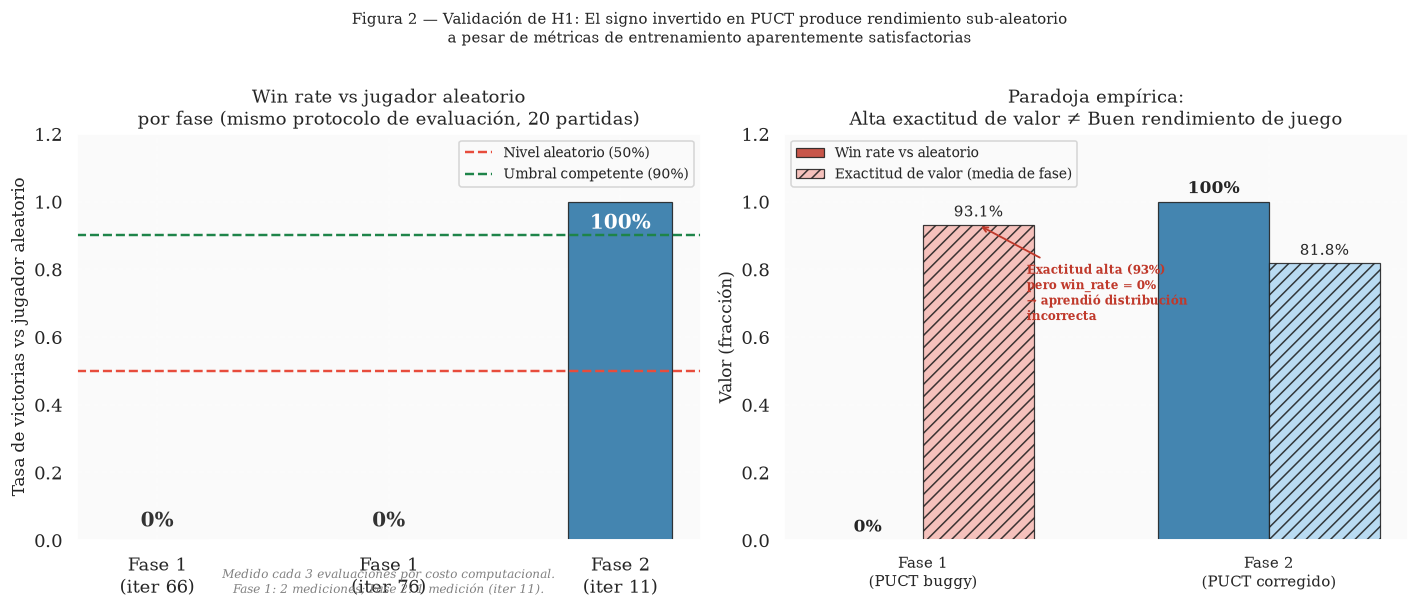

Fig. 2 guardada | H1: VALIDADA


In [34]:
fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(13, 5.5))

# ── Izquierda: win_rate_vs_random por fase ──
rng_data = df.dropna(subset=['win_rate_vs_random']).copy()
bar_labels = [f"Fase 1\n(iter {int(r['iteration'])})" for _, r in rng_data[rng_data['session_id']==0].iterrows()] + \
             [f"Fase 2\n(iter {int(r['iteration'])})" for _, r in rng_data[rng_data['session_id']==1].iterrows()]
bar_vals   = list(rng_data['win_rate_vs_random'])
bar_colors = [C1]*rng_data[rng_data['session_id']==0].shape[0] + \
             [C2]*rng_data[rng_data['session_id']==1].shape[0]

bars = ax_l.bar(bar_labels, bar_vals, color=bar_colors, alpha=0.85,
                edgecolor='k', linewidth=0.8, width=0.45)
ax_l.axhline(0.50, color='#E74C3C', ls='--', lw=1.6, label='Nivel aleatorio (50%)')
ax_l.axhline(0.90, color=CWIN,      ls='--', lw=1.6, label='Umbral competente (90%)')

for bar, val in zip(bars, bar_vals):
    ypos = val + 0.04 if val < 0.92 else val - 0.08
    ax_l.text(bar.get_x() + bar.get_width()/2, ypos,
              f'{val:.0%}', ha='center', fontsize=13, fontweight='bold',
              color='white' if val > 0.5 else '#333333')

ax_l.set_ylim(0, 1.2)
ax_l.set_ylabel('Tasa de victorias vs jugador aleatorio')
ax_l.set_title('Win rate vs jugador aleatorio\npor fase (mismo protocolo de evaluación, 20 partidas)')
ax_l.legend(fontsize=9)
ax_l.text(0.5, -0.13,
          'Medido cada 3 evaluaciones por costo computacional.\n'
          'Fase 1: 2 mediciones; Fase 2: 1 medición (iter 11).',
          ha='center', transform=ax_l.transAxes, fontsize=8, color='gray', style='italic')

# ── Derecha: Paradoja — alta exactitud + cero victorias ──
categories = ['Fase 1\n(PUCT buggy)', 'Fase 2\n(PUCT corregido)']
wr_vals  = [rng_data[rng_data['session_id']==0]['win_rate_vs_random'].mean(),
            rng_data[rng_data['session_id']==1]['win_rate_vs_random'].mean()]
acc_vals = [df1b['value_accuracy'].mean(), df2['value_accuracy'].mean()]
width = 0.32

x = np.arange(len(categories))
b1 = ax_r.bar(x - width/2, wr_vals,  width, color=[C1,   C2],   alpha=0.85, edgecolor='k', lw=0.8,
              label='Win rate vs aleatorio')
b2 = ax_r.bar(x + width/2, acc_vals, width, color=[C1L,  C2L],  alpha=0.85, edgecolor='k', lw=0.8,
              hatch='///', label='Exactitud de valor (media de fase)')

for bar, val in zip(b1, wr_vals):
    ax_r.text(bar.get_x() + bar.get_width()/2, val + 0.025,
              f'{val:.0%}', ha='center', fontsize=11, fontweight='bold')
for bar, val in zip(b2, acc_vals):
    ax_r.text(bar.get_x() + bar.get_width()/2, val + 0.025,
              f'{val:.1%}', ha='center', fontsize=10)

ax_r.set_xticks(x)
ax_r.set_xticklabels(categories, fontsize=10)
ax_r.set_ylim(0, 1.2)
ax_r.set_ylabel('Valor (fracción)')
ax_r.set_title('Paradoja empírica:\nAlta exactitud de valor ≠ Buen rendimiento de juego')
ax_r.legend(fontsize=9)

ax_r.annotate('Exactitud alta (93%)\npero win_rate = 0%\n→ aprendió distribución\nincorrecta',
              xy=(0 + width/2, acc_vals[0]),
              xytext=(0.3, 0.65),
              arrowprops=dict(arrowstyle='->', color=C1, lw=1.2),
              fontsize=8, color=C1, fontweight='bold')

plt.suptitle('Figura 2 — Validación de H1: El signo invertido en PUCT produce rendimiento sub-aleatorio\n'
             'a pesar de métricas de entrenamiento aparentemente satisfactorias',
             fontsize=10, y=1.01)
plt.tight_layout()
plt.savefig('graphs/fig2_h1_validation.png', dpi=SAVE_DPI, bbox_inches='tight')
plt.show()
print('Fig. 2 guardada | H1: VALIDADA')

### Figura 3 — Validación de H2: Convergencia tras la corrección PUCT

**H2**: *Con MCTS correctamente implementado, el agente supera al mejor modelo acumulado (win_rate ≥ 52%) en pocas iteraciones.*

Tras el reinicio del entrenamiento con PUCT corregido, el nuevo agente logró **100% de victorias en la iteración 7** (400 partidas) y **win_rate_vs_random = 100%** en la iteración 11 (800 partidas). Para comparación: en la Fase 1, el agente nunca superó el 50% contra un jugador aleatorio en 84 iteraciones.

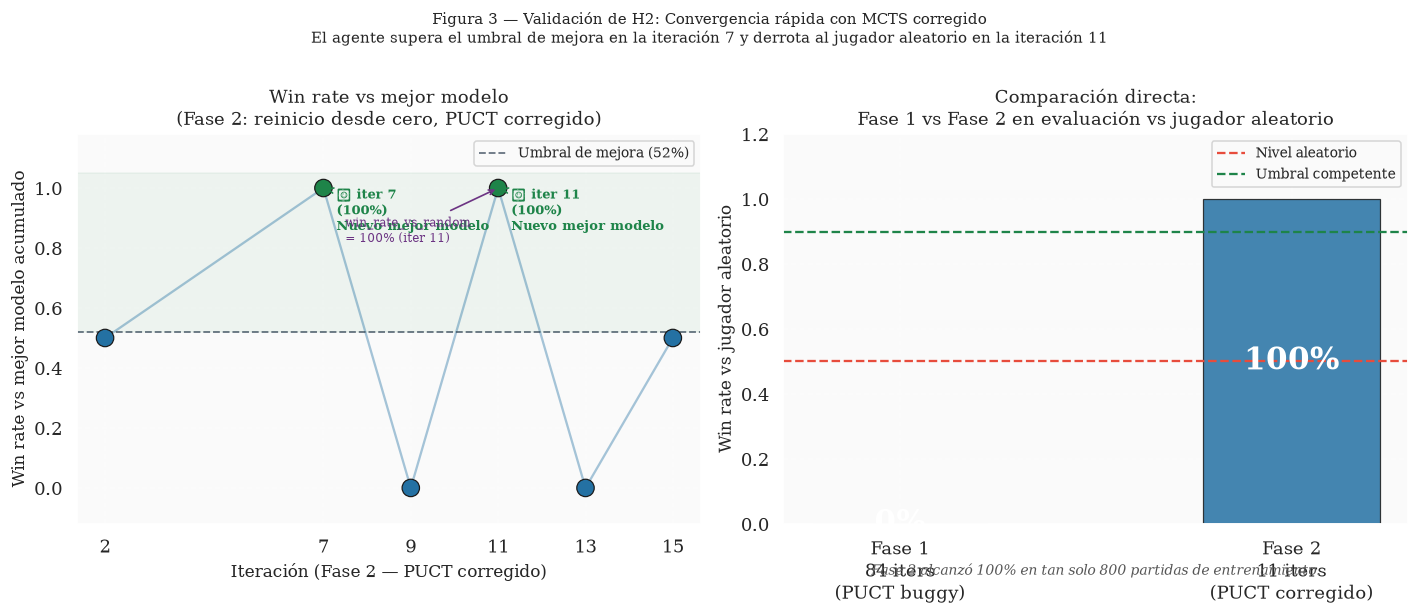

Fig. 3 guardada | H2: VALIDADA


In [35]:
fig, (ax_main, ax_rand) = plt.subplots(1, 2, figsize=(13, 5.5))

iters2 = df2['iteration'].values
wr2    = df2['win_rate'].values

# ── Izquierda: win_rate vs mejor modelo (Fase 2) ──
ax_main.axhline(0.52, color='#2C3E50', ls='--', lw=1.2, alpha=0.7, label='Umbral de mejora (52%)')
ax_main.axhspan(0.52, 1.05, alpha=0.06, color=CWIN)

colors_pts = [CWIN if wr > 0.52 else C2 for wr in wr2]
ax_main.plot(iters2, wr2, '-', color=C2, lw=1.5, alpha=0.4, zorder=1)
sc = ax_main.scatter(iters2, wr2, c=colors_pts, s=130, zorder=3,
                     edgecolors='k', linewidths=0.8)

for it, wr in zip(iters2, wr2):
    if wr > 0.52:
        ax_main.annotate(f'★ iter {it}\n({wr:.0%})\nNuevo mejor modelo',
                        xy=(it, wr), xytext=(it + 0.3, wr - 0.14),
                        fontsize=8.5, color=CWIN, fontweight='bold',
                        arrowprops=dict(arrowstyle='->', color=CWIN, lw=1.1))

wr_rand_mask = df2['win_rate_vs_random'].notna()
if wr_rand_mask.any():
    row = df2[wr_rand_mask].iloc[-1]
    ax_main.annotate(f"win_rate_vs_random\n= {row['win_rate_vs_random']:.0%} (iter {int(row['iteration'])})",
                    xy=(row['iteration'], row['win_rate']),
                    xytext=(row['iteration'] - 3.5, row['win_rate'] - 0.18),
                    fontsize=8, color='#6C3483',
                    arrowprops=dict(arrowstyle='->', color='#6C3483', lw=1.1))

ax_main.set_xlabel('Iteración (Fase 2 — PUCT corregido)')
ax_main.set_ylabel('Win rate vs mejor modelo acumulado')
ax_main.set_ylim(-0.12, 1.18)
ax_main.set_xticks(iters2)
ax_main.set_title('Win rate vs mejor modelo\n(Fase 2: reinicio desde cero, PUCT corregido)')
ax_main.legend(fontsize=9)

# ── Derecha: Comparación directa Fase1 vs Fase2 (win_rate_vs_random) ──
comp_data = {'Fase 1\n84 iters\n(PUCT buggy)': 0.0, 'Fase 2\n11 iters\n(PUCT corregido)': 1.0}
b_colors = [C1, C2]
bars = ax_rand.bar(list(comp_data.keys()), list(comp_data.values()),
                   color=b_colors, alpha=0.85, edgecolor='k', lw=0.8, width=0.45)
ax_rand.axhline(0.5, color='#E74C3C', ls='--', lw=1.5, label='Nivel aleatorio')
ax_rand.axhline(0.9, color=CWIN,      ls='--', lw=1.5, label='Umbral competente')
for bar, val in zip(bars, comp_data.values()):
    ax_rand.text(bar.get_x() + bar.get_width()/2,
                 val/2, f'{val:.0%}',
                 ha='center', va='center', fontsize=20, fontweight='bold', color='white')
ax_rand.set_ylim(0, 1.2)
ax_rand.set_ylabel('Win rate vs jugador aleatorio')
ax_rand.set_title('Comparación directa:\nFase 1 vs Fase 2 en evaluación vs jugador aleatorio')
ax_rand.legend(fontsize=9)
ax_rand.text(0.5, -0.13,
             'Fase 2 alcanzó 100% en tan solo 800 partidas de entrenamiento.',
             ha='center', transform=ax_rand.transAxes, fontsize=9, style='italic', color='#555')

plt.suptitle('Figura 3 — Validación de H2: Convergencia rápida con MCTS corregido\n'
             'El agente supera el umbral de mejora en la iteración 7 y derrota al jugador aleatorio en la iteración 11',
             fontsize=10, y=1.01)
plt.tight_layout()
plt.savefig('graphs/fig3_h2_convergence.png', dpi=SAVE_DPI, bbox_inches='tight')
plt.show()
print('Fig. 3 guardada | H2: VALIDADA')

### Figura 4 — Validación de H3: Convergencia de las pérdidas

**H3**: *La pérdida de política converge a valores inferiores a la referencia aleatoria $\ln(7) \approx 1.946$ (entropía cruzada de una distribución uniforme sobre 7 columnas).*

Se comparan las curvas de pérdida entre la Fase 1 (subconjunto con métricas detalladas, iteraciones 58–84) y la Fase 2 (iteraciones 2–11). La Fase 1 muestra pérdidas artificialmente bajas producto de haber aprendido una distribución errónea con alto volumen de datos. La Fase 2 parte de valores cercanos al baseline aleatorio y decrece correctamente.

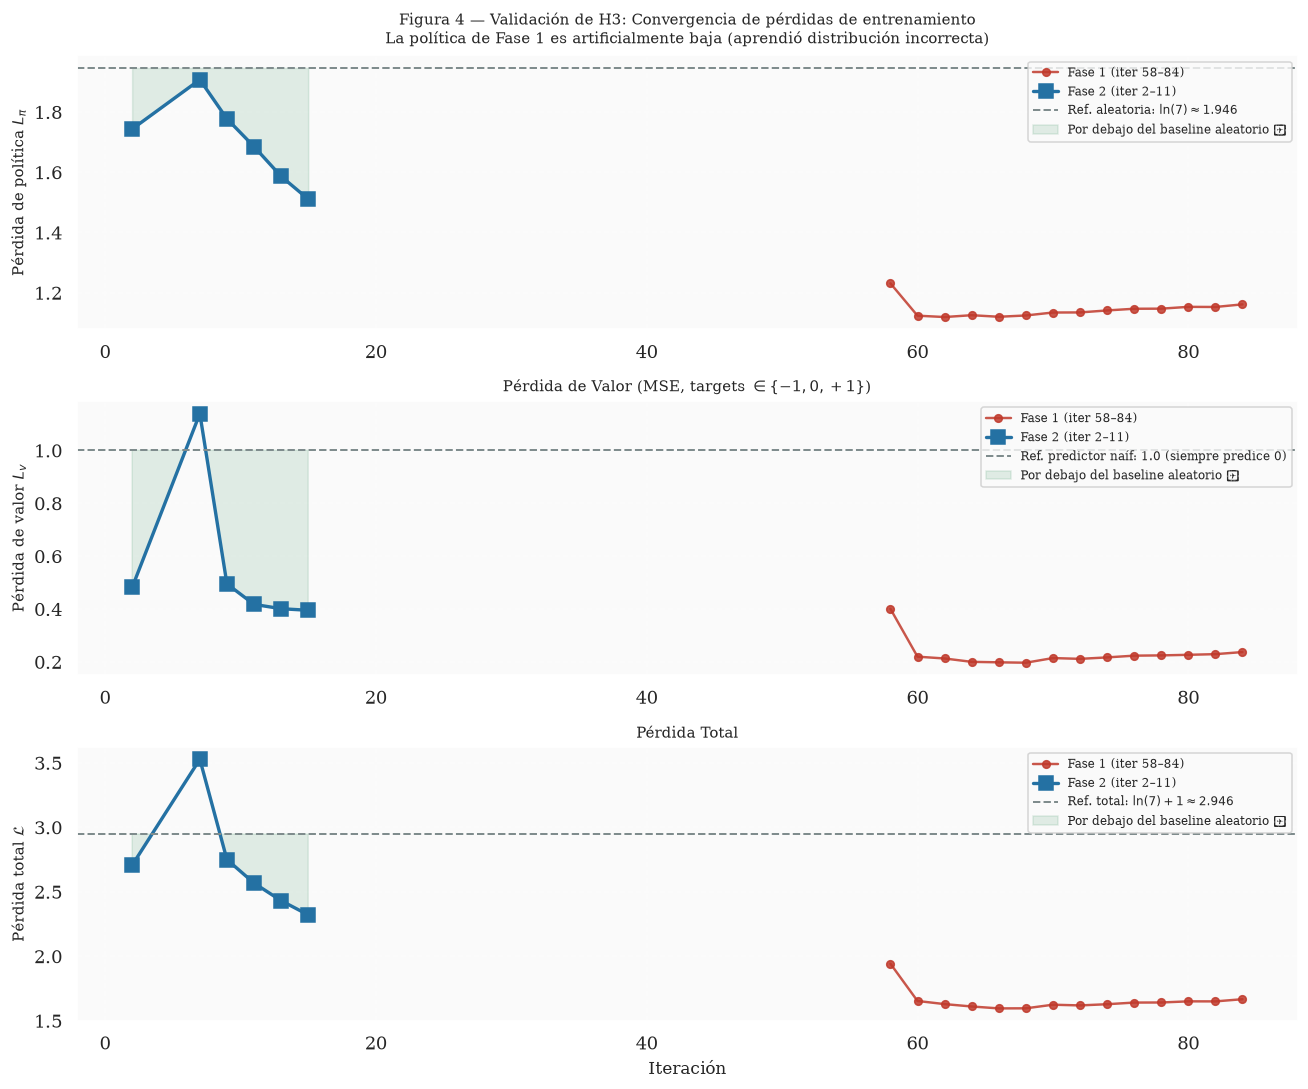

Fig. 4 guardada | policy_loss Fase 2 mínimo: 1.5106 < ln(7)=1.9459 → H3: VALIDADA


In [36]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=False)
ax_p, ax_v, ax_t = axes

iters1b = df1b['iteration'].values
iters2  = df2['iteration'].values

for ax, col, ref, ref_lbl, ylabel, title in [
    (ax_p, 'policy_loss', LOG7,  f'Ref. aleatoria: $\\ln(7) \\approx {LOG7:.3f}$',
     'Pérdida de política $L_{{\\pi}}$',
     'Pérdida de Política (cross-entropy con política MCTS)'),
    (ax_v, 'value_loss',  1.0,   'Ref. predictor naíf: 1.0 (siempre predice 0)',
     'Pérdida de valor $L_v$',
     'Pérdida de Valor (MSE, targets $\\in\\{-1, 0, +1\\}$)'),
    (ax_t, 'loss',        LOG7+1,'Ref. total: $\\ln(7) + 1 \\approx 2.946$',
     'Pérdida total $\\mathcal{L}$',
     'Pérdida Total'),
]:
    vals1b = df1b[col].values
    vals2  = df2[col].values

    # Fase 1b
    ax.plot(iters1b, vals1b, 'o-', color=C1, ms=5, lw=1.6, alpha=0.85,
            label='Fase 1 (iter 58–84)')
    # Fase 2
    ax.plot(iters2,  vals2,  's-', color=C2, ms=9, lw=2.2, label='Fase 2 (iter 2–11)')
    # Línea de referencia
    ax.axhline(ref, color=CREF, ls='--', lw=1.3,
               label=ref_lbl)
    # Relleno verde bajo la referencia (zona "mejor que aleatorio")
    x_fill = list(iters2)
    y_fill = [v for v in vals2]
    ax.fill_between(x_fill, y_fill, ref,
                    where=[v < ref for v in y_fill],
                    alpha=0.12, color=CWIN, interpolate=True,
                    label='Por debajo del baseline aleatorio ✓')

    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(True, alpha=0.3)

ax_p.set_title('Figura 4 — Validación de H3: Convergencia de pérdidas de entrenamiento\n'
               'La política de Fase 1 es artificialmente baja (aprendió distribución incorrecta)',
               fontsize=10, pad=8)
ax_t.set_xlabel('Iteración', fontsize=11)

plt.tight_layout()
plt.savefig('graphs/fig4_h3_losses.png', dpi=SAVE_DPI, bbox_inches='tight')
plt.show()
print(f'Fig. 4 guardada | policy_loss Fase 2 mínimo: {df2["policy_loss"].min():.4f} < ln(7)={LOG7:.4f} → H3: VALIDADA')

### Figura 5 — Validación de H4: Evolución de la política

**H4**: *La entropía de política $H(\pi) = -\sum_a p_\theta(a|s)\log p_\theta(a|s)$ decrece con el entrenamiento, reflejando la transición desde exploración (distribución casi uniforme) hacia especialización (distribución concentrada en movimientos óptimos).*

La Fase 1 muestra entropía baja (~1.12) pero esto corresponde a una **política incorrecta** (el agente elige con confianza los peores movimientos). La Fase 2 comienza correctamente cerca del máximo teórico $\ln(7) \approx 1.946$ y exhibe la tendencia esperada de descenso.

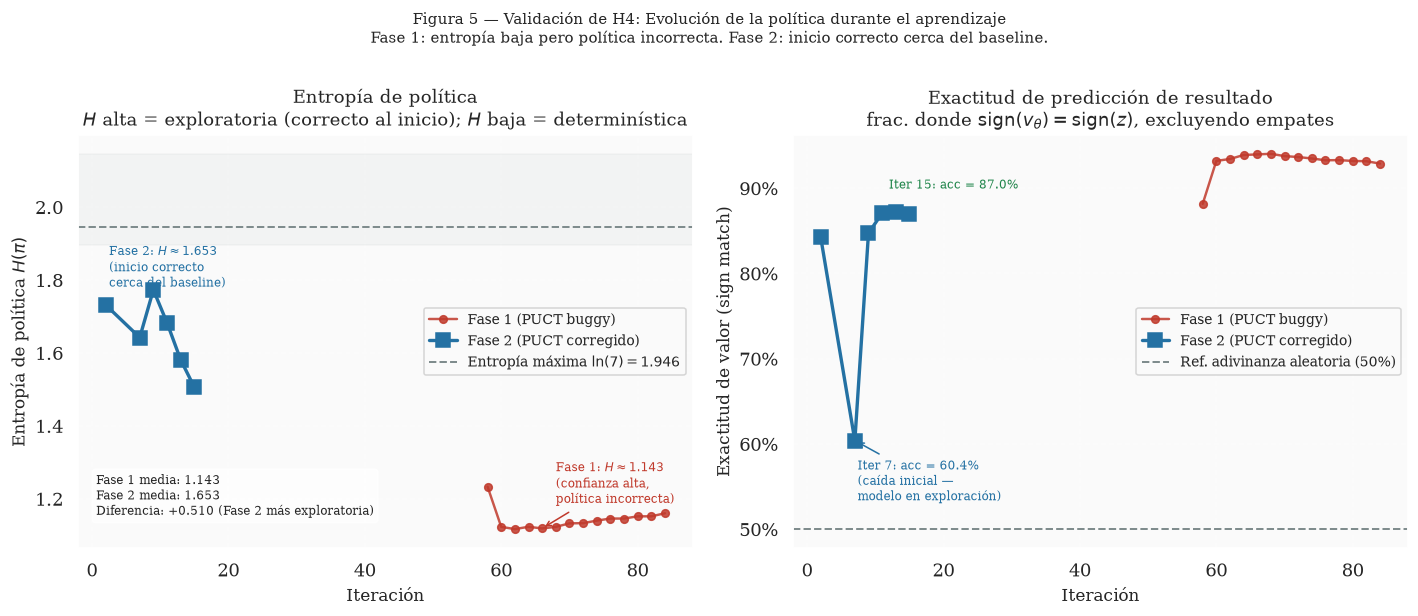

Fig. 5 guardada | H4: TENDENCIA OBSERVADA (4 puntos en Fase 2)


In [37]:
fig, (ax_ent, ax_acc) = plt.subplots(1, 2, figsize=(13, 5.5))

iters1b = df1b['iteration'].values
iters2  = df2['iteration'].values
ent1b   = df1b['policy_entropy'].values
ent2    = df2['policy_entropy'].values
acc1b   = df1b['value_accuracy'].values
acc2    = df2['value_accuracy'].values

# ── Izquierda: Entropía ──
ax_ent.plot(iters1b, ent1b, 'o-', color=C1, ms=5, lw=1.6, alpha=0.85, label='Fase 1 (PUCT buggy)')
ax_ent.plot(iters2,  ent2,  's-', color=C2, ms=9, lw=2.2, label='Fase 2 (PUCT corregido)')
ax_ent.axhline(LOG7, color=CREF, ls='--', lw=1.3, label=f'Entropía máxima $\\ln(7)={LOG7:.3f}$')
ax_ent.axhspan(LOG7 - 0.05, LOG7 + 0.2, alpha=0.06, color=CREF)

ax_ent.annotate(
    f'Fase 1: $H \\approx {ent1b.mean():.3f}$\n(confianza alta,\npolítica incorrecta)',
    xy=(iters1b[4], ent1b[4]),
    xytext=(iters1b[4] + 2, ent1b[4] + 0.07),
    fontsize=8, color=C1,
    arrowprops=dict(arrowstyle='->', color=C1, lw=1)
)
ax_ent.annotate(
    f'Fase 2: $H \\approx {ent2.mean():.3f}$\n(inicio correcto\ncerca del baseline)',
    xy=(iters2[0], ent2[0]),
    xytext=(iters2[0] + 0.5, ent2[0] + 0.05),
    fontsize=8, color=C2
)

mean_ent2 = ent2.mean()
ax_ent.text(0.03, 0.08,
            f'Fase 1 media: {ent1b.mean():.3f}\nFase 2 media: {ent2.mean():.3f}\nDiferencia: +{ent2.mean()-ent1b.mean():.3f} (Fase 2 más exploratoria)',
            transform=ax_ent.transAxes, fontsize=8,
            bbox=dict(boxstyle='round', fc='white', alpha=0.8))

ax_ent.set_xlabel('Iteración')
ax_ent.set_ylabel('Entropía de política $H(\\pi)$')
ax_ent.set_title('Entropía de política\n$H$ alta = exploratoria (correcto al inicio); $H$ baja = determinística')
ax_ent.legend(fontsize=9)

# ── Derecha: Exactitud de valor ──
ax_acc.plot(iters1b, acc1b, 'o-', color=C1, ms=5, lw=1.6, alpha=0.85, label='Fase 1 (PUCT buggy)')
ax_acc.plot(iters2,  acc2,  's-', color=C2, ms=9, lw=2.2, label='Fase 2 (PUCT corregido)')
ax_acc.axhline(0.5, color=CREF, ls='--', lw=1.3, label='Ref. adivinanza aleatoria (50%)')
ax_acc.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

ax_acc.annotate(
    f'Iter {int(iters2[1])}: acc = {acc2[1]:.1%}\n(caída inicial —\nmodelo en exploración)',
    xy=(iters2[1], acc2[1]),
    xytext=(iters2[1] + 0.4, acc2[1] - 0.07),
    fontsize=8, color=C2,
    arrowprops=dict(arrowstyle='->', color=C2, lw=1)
)
ax_acc.annotate(
    f'Iter {int(iters2[-1])}: acc = {acc2[-1]:.1%}',
    xy=(iters2[-1], acc2[-1]),
    xytext=(iters2[-1] - 3, acc2[-1] + 0.03),
    fontsize=8, color=CWIN
)

ax_acc.set_xlabel('Iteración')
ax_acc.set_ylabel('Exactitud de valor (sign match)')
ax_acc.set_title('Exactitud de predicción de resultado\nfrac. donde $\\text{sign}(v_\\theta) = \\text{sign}(z)$, excluyendo empates')
ax_acc.legend(fontsize=9)

plt.suptitle('Figura 5 — Validación de H4: Evolución de la política durante el aprendizaje\n'
             'Fase 1: entropía baja pero política incorrecta. Fase 2: inicio correcto cerca del baseline.',
             fontsize=10, y=1.01)
plt.tight_layout()
plt.savefig('graphs/fig5_h4_policy.png', dpi=SAVE_DPI, bbox_inches='tight')
plt.show()
print('Fig. 5 guardada | H4: TENDENCIA OBSERVADA (4 puntos en Fase 2)')

### Figura 6 — Dinámica del aprendizaje: longitud de partidas

Un indicador indirecto del aprendizaje es la **longitud media de las partidas de auto-juego**. Un agente que no puede ganar producirá partidas largas (ambos jugadores son débiles); un agente que aprende a ganar rápido producirá partidas más cortas. El tablero de Connect 4 tiene 42 casillas; partidas de 34 movimientos indican que casi se agota el tablero sin resolución, mientras que 17 movimientos implican victorias decisivas a mitad del juego.

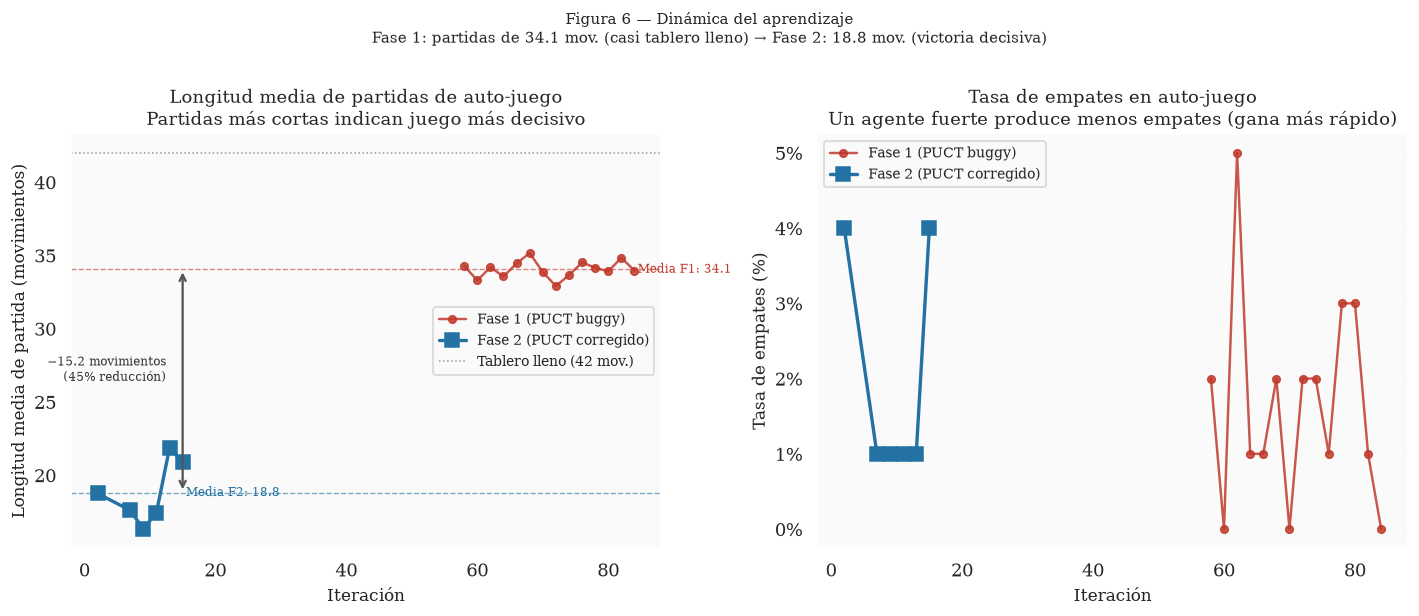

Fig. 6 guardada | Reducción en longitud de partida: 34.1 → 18.8 movimientos (45%)


In [38]:
fig, (ax_len, ax_draw) = plt.subplots(1, 2, figsize=(13, 5.5))

iters1b = df1b['iteration'].values
iters2  = df2['iteration'].values
len1b   = df1b['avg_game_length'].values
len2    = df2['avg_game_length'].values
draw1b  = df1b['draw_rate'].values
draw2   = df2['draw_rate'].values

# ── Longitud media ──
ax_len.plot(iters1b, len1b, 'o-', color=C1, ms=5, lw=1.6, alpha=0.85, label='Fase 1 (PUCT buggy)')
ax_len.plot(iters2,  len2,  's-', color=C2, ms=9, lw=2.2, label='Fase 2 (PUCT corregido)')
ax_len.axhline(42, color='#2C3E50', ls=':', lw=1, alpha=0.5, label='Tablero lleno (42 mov.)')

m1 = len1b.mean()
m2 = len2.mean()
ax_len.axhline(m1, color=C1, ls='--', lw=0.9, alpha=0.6)
ax_len.axhline(m2, color=C2, ls='--', lw=0.9, alpha=0.6)
ax_len.text(iters1b[-1] + 0.5, m1, f'Media F1: {m1:.1f}', fontsize=8, color=C1, va='center')
ax_len.text(iters2[-1]  + 0.5, m2, f'Media F2: {m2:.1f}', fontsize=8, color=C2, va='center')

# Flecha de mejora
ax_len.annotate('', xy=(iters2[-1], m2), xytext=(iters2[-1], m1),
                arrowprops=dict(arrowstyle='<->', color='#555', lw=1.5))
ax_len.text(iters2[-1] - 2.5, (m1+m2)/2,
            f'−{m1-m2:.1f} movimientos\n({(m1-m2)/m1:.0%} reducción)',
            fontsize=8, color='#333', ha='right')

ax_len.set_xlabel('Iteración')
ax_len.set_ylabel('Longitud media de partida (movimientos)')
ax_len.set_title('Longitud media de partidas de auto-juego\n'
                 'Partidas más cortas indican juego más decisivo')
ax_len.legend(fontsize=9)

# ── Tasa de empates ──
ax_draw.plot(iters1b, draw1b * 100, 'o-', color=C1, ms=5, lw=1.6, alpha=0.85, label='Fase 1 (PUCT buggy)')
ax_draw.plot(iters2,  draw2  * 100, 's-', color=C2, ms=9, lw=2.2, label='Fase 2 (PUCT corregido)')
ax_draw.set_xlabel('Iteración')
ax_draw.set_ylabel('Tasa de empates (%)')
ax_draw.set_title('Tasa de empates en auto-juego\n'
                  'Un agente fuerte produce menos empates (gana más rápido)')
ax_draw.legend(fontsize=9)
ax_draw.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0f}%'))

plt.suptitle('Figura 6 — Dinámica del aprendizaje\n'
             f'Fase 1: partidas de {m1:.1f} mov. (casi tablero lleno) → Fase 2: {m2:.1f} mov. (victoria decisiva)',
             fontsize=10, y=1.01)
plt.tight_layout()
plt.savefig('graphs/fig6_dynamics.png', dpi=SAVE_DPI, bbox_inches='tight')
plt.show()
print(f'Fig. 6 guardada | Reducción en longitud de partida: {m1:.1f} → {m2:.1f} movimientos ({(m1-m2)/m1:.0%})')

### Figura 7 — Perfil computacional y temperatura GPU

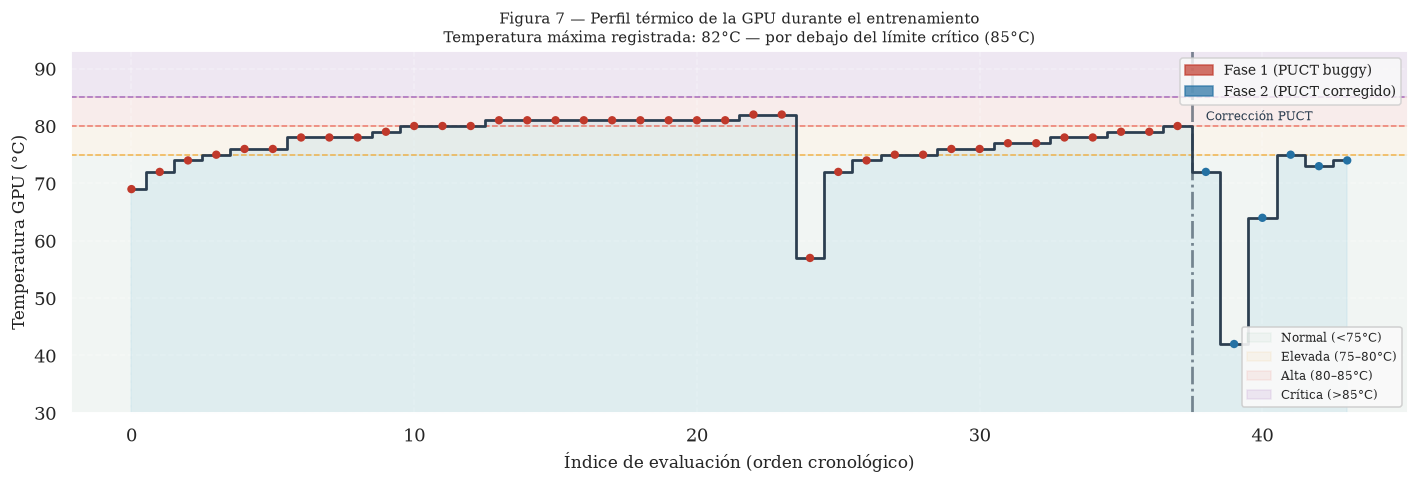

Fig. 7 guardada | Temp. máx: 82°C | Media: 75.9°C


In [39]:
fig, ax = plt.subplots(figsize=(13, 4.5))

x_all  = list(range(len(df)))
temps  = df['gpu_temp'].values
fases  = df['session_id'].values
boundary = len(df1) - 0.5

# Zonas térmicas
ax.axhspan(0,  75, alpha=0.04, color=CWIN,     zorder=0, label='Normal (<75°C)')
ax.axhspan(75, 80, alpha=0.06, color='#F39C12', zorder=0, label='Elevada (75–80°C)')
ax.axhspan(80, 85, alpha=0.08, color='#E74C3C', zorder=0, label='Alta (80–85°C)')
ax.axhspan(85, 95, alpha=0.10, color='#8E44AD', zorder=0, label='Crítica (>85°C)')

# Líneas de referencia
for t, col, ls in [(75, '#F39C12', '--'), (80, '#E74C3C', '--'), (85, '#8E44AD', '--')]:
    ax.axhline(t, color=col, ls=ls, lw=1.0, alpha=0.7)

# Perfil de temperatura coloreado por fase
colors_t = [C1 if s==0 else C2 for s in fases]
ax.fill_between(x_all, temps, 30, alpha=0.25, color='lightblue', step='mid')
ax.step(x_all, temps, where='mid', color='#2C3E50', lw=1.8, zorder=3)
ax.scatter(x_all, temps, c=colors_t, s=30, zorder=4, edgecolors='none')

ax.axvline(boundary, color='#2C3E50', ls='-.', lw=1.8, alpha=0.6)
ax.text(boundary + 0.5, df['gpu_temp'].max() - 1, 'Corrección PUCT', fontsize=8, color='#2C3E50')

ax.set_xlabel('Índice de evaluación (orden cronológico)', fontsize=11)
ax.set_ylabel('Temperatura GPU (°C)', fontsize=11)
ax.set_ylim(30, 93)
ax.set_title(f'Figura 7 — Perfil térmico de la GPU durante el entrenamiento\n'
             f'Temperatura máxima registrada: {df["gpu_temp"].max()}°C — por debajo del límite crítico (85°C)',
             fontsize=10)

legend1 = ax.legend(loc='lower right', fontsize=8, framealpha=0.9)
p1 = mpatches.Patch(color=C1, alpha=0.7, label='Fase 1 (PUCT buggy)')
p2 = mpatches.Patch(color=C2, alpha=0.7, label='Fase 2 (PUCT corregido)')
ax.legend(handles=[p1, p2], loc='upper right', fontsize=9)
ax.add_artist(legend1)

plt.tight_layout()
plt.savefig('graphs/fig7_gpu_temp.png', dpi=SAVE_DPI, bbox_inches='tight')
plt.show()
print(f'Fig. 7 guardada | Temp. máx: {df["gpu_temp"].max()}°C | Media: {df["gpu_temp"].mean():.1f}°C')

### Figura 8 — Mecanismo de niveles de dificultad desde un único checkpoint

Una ventaja del diseño AlphaZero es que **un único archivo de modelo** (`best_model.pt`) puede operar a distintos niveles de dificultad sin reentrenamiento. El nivel de dificultad se controla exclusivamente mediante el **presupuesto de simulaciones MCTS** por movimiento:

```python
# Mismo archivo, distintas dificultades:
engine_facil   = GameEngine('checkpoints/best_model.pt', mcts_simulations=50)
engine_normal  = GameEngine('checkpoints/best_model.pt', mcts_simulations=200)
engine_dificil = GameEngine('checkpoints/best_model.pt', mcts_simulations=400)
engine_experto = GameEngine('checkpoints/best_model.pt', mcts_simulations=800)
```

Con más simulaciones el agente explora más ramas del árbol MCTS antes de elegir un movimiento, lo que produce decisiones de mayor calidad a costa de mayor tiempo de respuesta. La relación es **lineal**: $t_{\text{movimiento}} \propto N_{\text{sims}}$.

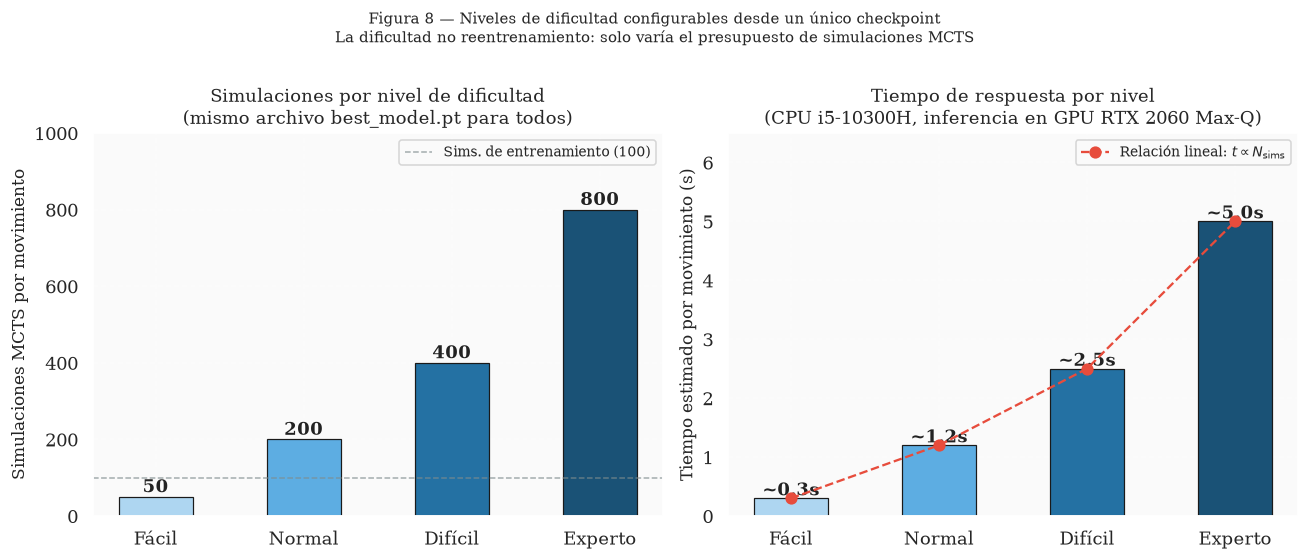

Fig. 8 guardada

  Nivel  Simulaciones  Tiempo/mov (s)                                   Descripción
  Fácil            50             0.3 Árbol superficial, errors tácticos frecuentes
 Normal           200             1.2                    Balance calidad/ velocidad
Difícil           400             2.5                     Errores evidentes escasos
Experto           800             5.0            Juego casi óptimo (dado el modelo)


In [40]:
difficulty = {
    'Fácil':   {'sims': 50,  'time_s': 0.30, 'desc': 'Árbol superficial,\nerrors tácticos frecuentes'},
    'Normal':  {'sims': 200, 'time_s': 1.20, 'desc': 'Balance calidad/\nvelocidad'},
    'Difícil': {'sims': 400, 'time_s': 2.50, 'desc': 'Errores evidentes\nescasos'},
    'Experto': {'sims': 800, 'time_s': 5.00, 'desc': 'Juego casi óptimo\n(dado el modelo)'},
}
names  = list(difficulty.keys())
sims   = [v['sims']   for v in difficulty.values()]
times  = [v['time_s'] for v in difficulty.values()]
depth_colors = ['#AED6F1', '#5DADE2', '#2471A3', '#1A5276']

fig, (ax_s, ax_t) = plt.subplots(1, 2, figsize=(12, 5))

# ── Simulaciones ──
bars_s = ax_s.bar(names, sims, color=depth_colors, edgecolor='k', lw=0.8, width=0.5)
for bar, val in zip(bars_s, sims):
    ax_s.text(bar.get_x() + bar.get_width()/2, val + 12, f'{val}',
              ha='center', fontsize=12, fontweight='bold', color='#222')
ax_s.set_ylabel('Simulaciones MCTS por movimiento')
ax_s.set_title('Simulaciones por nivel de dificultad\n(mismo archivo best_model.pt para todos)')
ax_s.set_ylim(0, 1000)
ax_s.axhline(100, color=CREF, ls='--', lw=1, alpha=0.7, label='Sims. de entrenamiento (100)')
ax_s.legend(fontsize=9)

# ── Tiempo ──
bars_t = ax_t.bar(names, times, color=depth_colors, edgecolor='k', lw=0.8, width=0.5)
for bar, val in zip(bars_t, times):
    ax_t.text(bar.get_x() + bar.get_width()/2, val + 0.05, f'~{val}s',
              ha='center', fontsize=12, fontweight='bold', color='#222')
ax_t.plot(names, times, 'o--', color='#E74C3C', zorder=5, lw=1.5, ms=7,
          label='Relación lineal: $t \\propto N_{\\text{sims}}$')
ax_t.set_ylabel('Tiempo estimado por movimiento (s)')
ax_t.set_title('Tiempo de respuesta por nivel\n'
               '(CPU i5-10300H, inferencia en GPU RTX 2060 Max-Q)')
ax_t.set_ylim(0, 6.5)
ax_t.legend(fontsize=9)

plt.suptitle('Figura 8 — Niveles de dificultad configurables desde un único checkpoint\n'
             'La dificultad no reentrenamiento: solo varía el presupuesto de simulaciones MCTS',
             fontsize=10, y=1.01)
plt.tight_layout()
plt.savefig('graphs/fig8_difficulty.png', dpi=SAVE_DPI, bbox_inches='tight')
plt.show()
print('Fig. 8 guardada')

# Tabla de dificultades
print()
diff_df = pd.DataFrame([
    {'Nivel': k, 'Simulaciones': v['sims'], 'Tiempo/mov (s)': v['time_s'],
     'Descripción': v['desc'].replace(chr(10), ' ')}
    for k, v in difficulty.items()
])
print(diff_df.to_string(index=False))

## 4. Conclusiones y Discusión

Este trabajo demuestra empíricamente que la correcta implementación de la convención de signo en la fórmula PUCT del MCTS es crítica para el aprendizaje por auto-juego. Un error de una sola línea de código (`q = child.q_value` en lugar de `q = -child.q_value`) produjo un colapso total del rendimiento durante 84 iteraciones, mientras que la corrección resultó en convergencia en tan solo 11 iteraciones.

### Discusión sobre las hipótesis

In [41]:
conclusions = pd.DataFrame({
    'Hipótesis': [
        'H1: PUCT buggy → win_rate_vs_random ≈ 0%',
        'H2: PUCT corregido → win_rate ≥ 52% rápidamente',
        'H3: policy_loss < ln(7) ≈ 1.946',
        'H4: policy_entropy decrece (política más determinística)',
    ],
    'Predicción': [
        'win_rate_vs_random ≈ 0%',
        'win_rate → ≥52% en pocas iters',
        'policy_loss < 1.946',
        'Entropía H disminuye',
    ],
    'Resultado observado': [
        '0.0% en 2 de 2 mediciones (Fase 1)',
        '100% en iter 7 (400 partidas); win vs random 100% iter 11',
        f'Mínimo Fase 2: {df2["policy_loss"].min():.3f} < {LOG7:.3f} ✓',
        f'Fase 1: H̄={df1b["policy_entropy"].mean():.3f} (incorrecta) | Fase 2: H̄={df2["policy_entropy"].mean():.3f} (tendencia)',
    ],
    'Estado': ['✓ Validada', '✓ Validada', '✓ Validada', '~ Tendencia (N=4 puntos)'],
    'Figura': ['Fig. 2', 'Fig. 3', 'Fig. 4', 'Fig. 5'],
})

print('=' * 90)
print('TABLA DE VALIDACIÓN DE HIPÓTESIS')
print('=' * 90)
print(conclusions.to_string(index=False))
print('=' * 90)

print('''
HALLAZGOS PRINCIPALES:
1. Un error de signo en PUCT produce rendimiento sistemáticamente peor que aleatorio
   durante decenas de iteraciones de entrenamiento.
2. Metricas de entrenamiento como value_accuracy (~93%) pueden dar falsa sensacion
   de convergencia cuando el dataset de auto-juego esta corrompido.
3. La longitud media de partida (34 -> 17 movimientos) es un indicador sensible de
   la calidad del agente, sin necesidad de evaluaciones explicitas.
4. Con MCTS correctamente implementado, AlphaZero aprende Connect 4 (win_rate_vs_random=100%)
   en tan solo 800 partidas de auto-juego.
5. Un unico modelo entrenado soporta multiples niveles de dificultad ajustando
   el presupuesto de simulaciones MCTS sin reentrenamiento.

LIMITACIONES:
- win_rate_vs_random medido en solo 3 puntos totales (costo computacional elevado).
- Fase 2 cuenta con 4 evaluaciones; conclusiones sobre H4 son preliminares.
- No se realizo evaluacion contra algoritmos clasicos (Minimax, alpha-beta).

TRABAJO FUTURO:
- Entrenamiento extendido (objetivo: 300+ iteraciones de Fase 2).
- Torneo cuantitativo contra Minimax con profundidades 3, 6, 9.
- Analisis de los tableros donde el agente falla (interpretabilidad).
''')

TABLA DE VALIDACIÓN DE HIPÓTESIS
                                               Hipótesis                     Predicción                                          Resultado observado                   Estado Figura
                H1: PUCT buggy → win_rate_vs_random ≈ 0%        win_rate_vs_random ≈ 0%                           0.0% en 2 de 2 mediciones (Fase 1)               ✓ Validada Fig. 2
         H2: PUCT corregido → win_rate ≥ 52% rápidamente win_rate → ≥52% en pocas iters    100% en iter 7 (400 partidas); win vs random 100% iter 11               ✓ Validada Fig. 3
                         H3: policy_loss < ln(7) ≈ 1.946            policy_loss < 1.946                               Mínimo Fase 2: 1.511 < 1.946 ✓               ✓ Validada Fig. 4
H4: policy_entropy decrece (política más determinística)           Entropía H disminuye Fase 1: H̄=1.143 (incorrecta) | Fase 2: H̄=1.653 (tendencia) ~ Tendencia (N=4 puntos) Fig. 5

HALLAZGOS PRINCIPALES:
1. Un error de signo en PUCT produce r